In [2]:
# write function to extract X random subsequences of percentage N from each sequence in a FASTA file
import gzip
import random
from Bio import SeqIO
import os

def extract_random_subsequences_percentage(input_fasta, output_fasta, X, percentage):
    if os.path.exists(output_fasta):
        print(f"Output file {output_fasta} already exists. Skipping extraction.")
        return
    with gzip.open(input_fasta, 'rt') if input_fasta.endswith('.gz') else open(input_fasta, 'r') as input_fasta:
        with open(output_fasta, 'w') as out_f:
            for record in SeqIO.parse(input_fasta, "fasta"):
                for _ in range(X):
                    seq_len = len(record.seq)
                    N = int(seq_len * percentage / 100)
                    if seq_len < N:
                        print(f"Skipping {record.id}: sequence length < {N}")
                        continue
                    start = random.randint(0, seq_len - N)
                    subseq = record.seq[start:start + N]
                    new_record = record[:]
                    new_record.seq = subseq
                    new_record.id = f"{record.id}_iter{_}_subseq{start}_{start + N - 1}"
                    SeqIO.write(new_record, out_f, "fasta")

# Example usage:
# extract_random_subsequences("input.fasta", "output.fasta", 100)

In [3]:
# create 5 replicates of 1000 random fragments of length 50% and 90% of each genome
!mkdir -p phage_fragments

for i in [1, 2, 3, 4, 5]:
    for j in [1]:
        for N in [20, 40, 60, 80]:
            extract_random_subsequences_percentage(
                f"gut_hq_viruses/gut_reps_split/gut_reps.part_00{i}.fna",
                f"gut_hq_viruses/gut_reps_split/gut_reps.part_00{i}.fragment_perc{N}.fna",
                j,
                N
            )

In [ ]:
%%bash
for i in {1..5}; do
    for j in 20 40 60 80; do
        iss \
            generate \
            --seed 1 \
            --genomes gut_hq_viruses/gut_reps_split/gut_reps.part_00${i}.fragment_perc${j}.fna \
            --model nextseq \
            --cpus 4 \
            --abundance lognormal \
            --n_reads 100000 \
            --compress \
            --output readsim/fragment${j}_split_${i}_reads

            rm readsim/fragment${j}_split_${i}_reads.iss.tmp.*.vcf
    done
done


In [ ]:
%%bash
for i in {1..5}; do
    for j in 20 40 60 80; do

        mkdir -p uhvdb_sylph_profile/fragment_split_${i}

        sylph profile \
            uhvdb_r2025_09.votu_reps.c200.syldb \
            globdb_r226_sylph_c1000.syldb \
            -1 readsim/fragment${j}_split_${i}_reads_R1.fastq.gz \
            -2 readsim/fragment${j}_split_${i}_reads_R2.fastq.gz \
            --output-file uhvdb_sylph_profile/fragment_split_${i}/fragment${j}_split_${i}_uhvdb_globdb.profile.tsv \
            -t 32 \
            --min-number-kmers 3 \
            --estimate-unknown > uhvdb_sylph_profile/fragment_split_${i}/fragment${j}_split_${i}_uhvdb_globdb.profile.log 2>&1
    done
done

In [1]:
import polars as pl
for i in range(6, 18):
    # load sylph query to identify contained species
    (
        pl.read_csv(f'uhvdb_sylph_profile/split_{i}/split_{i}_uhvdb_globdb.profile.tsv', separator='\t', ignore_errors=True)
            .with_columns([
                pl.col('Contig_name').str.split(' ').list[0].alias('contig_id')
            ])
            [['contig_id']]
            .write_csv(f'uhvdb_sylph_profile/split_{i}/split_{i}_uhvdb_globdb.contained_genomes.tsv', separator='\t', include_header=False)
    )

In [ ]:
%%bash
# full genome coverm
for i in {6..17}; do
    seqkit grep \
        /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/uhvdb_final_files/r2025_09/uhvdb_votu_reps.fna.gz \
        --pattern-file uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.contained_genomes.tsv \
        -o uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.contained_genomes.fna.gz

    coverm contig \
        --coupled readsim/split_${i}_reads_R1.fastq.gz \
        readsim/split_${i}_reads_R2.fastq.gz \
        --reference uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.contained_genomes.fna.gz \
        --mapper strobealign \
        --methods trimmed_mean mean covered_bases length \
        --output-file uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.coverm.tsv \
        --min-read-percent-identity 92 \
        --min-read-aligned-percent 90 \
        --threads 48 \
        --bam-file-cache-directory uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.coverm.bam
    done
done


In [3]:
import polars as pl
for i in range(1, 6):
    for j in [20, 40, 60, 80]:
        # load sylph query to identify contained species
        (
            pl.read_csv(f'uhvdb_sylph_profile/fragment_split_{i}/fragment{j}_split_{i}_uhvdb_globdb.profile.tsv', separator='\t', ignore_errors=True)
                .with_columns([
                    pl.col('Contig_name').str.split(' ').list[0].alias('contig_id')
                ])
                [['contig_id']]
                .write_csv(f'uhvdb_sylph_profile/fragment_split_{i}/fragment{j}_split_{i}_uhvdb_globdb.contained_genomes.tsv', separator='\t', include_header=False)
        )

In [ ]:
%%bash
### fragment genome coverm ###
for i in {1..5}; do
    for j in 20 40 60 80; do
        seqkit grep \
            /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/uhvdb_final_files/r2025_09/uhvdb_votu_reps.fna.gz \
            --pattern-file uhvdb_sylph_profile/fragment_split_${i}/fragment${j}_split_${i}_uhvdb_globdb.contained_genomes.tsv \
            -o uhvdb_sylph_profile/fragment_split_${i}/fragment${j}_split_${i}_uhvdb_globdb.contained_genomes.fna.gz

        coverm contig \
            --coupled readsim/fragment${j}_split_${i}_reads_R1.fastq.gz \
            readsim/fragment${j}_split_${i}_reads_R2.fastq.gz \
            --reference uhvdb_sylph_profile/fragment_split_${i}/fragment${j}_split_${i}_uhvdb_globdb.contained_genomes.fna.gz \
            --mapper strobealign \
            --methods trimmed_mean mean covered_bases length \
            --output-file uhvdb_sylph_profile/fragment_split_${i}/fragment${j}_split_${i}_uhvdb_globdb.coverm.tsv \
            --threads 48 \
            --min-read-percent-identity 92 \
            --min-read-aligned-percent 90
    done
done


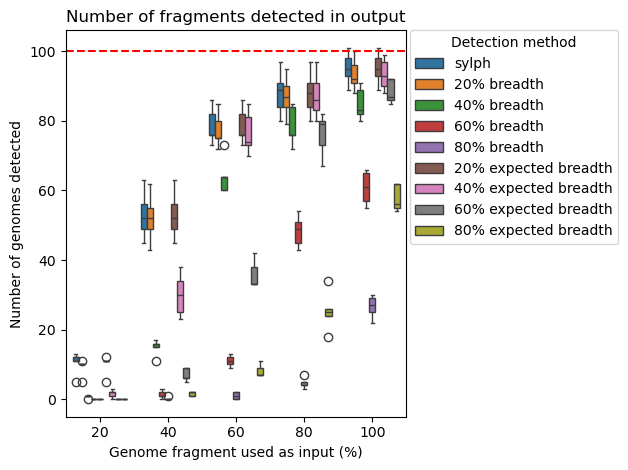

In [27]:
### Compare number of sylph genomes to coverM with 50%, 60%, 70%, 80% breadth
import polars as pl
import math

dict_lst = []

for i in range(1, 6):
    for j in [20, 40, 60, 80]:
        # read sylph outputs
        seq_count = (
            pl.read_csv(f'uhvdb_sylph_profile/fragment_split_{i}/fragment{j}_split_{i}_uhvdb_globdb.profile.tsv', separator='\t', ignore_errors=True)
                .height
        )
        dict_lst.append({
            'replicate': i,
            'fragment_percentage': j,
            'method': f'sylph',
            'num_genomes': seq_count
        })
        # read coverm outputs
        for k in [20, 40, 60, 80, 21, 41, 61, 81]:
            coverm_df = pl.read_csv(f'uhvdb_sylph_profile/fragment_split_{i}/fragment{j}_split_{i}_uhvdb_globdb.coverm.tsv', separator='\t', ignore_errors=True, new_columns=['contig_id', 'trimmed_mean', 'mean', 'covered_bases', 'length'])
            if k in [21, 41, 61, 81]:
                covered_genomes = (
                    coverm_df
                        .with_columns([
                            (pl.col('covered_bases') / pl.col('length')).alias('breadth'),
                        ])
                        .with_columns([
                            (1 - math.e**(-0.833 * pl.col('mean'))).alias('expected_breadth'),
                        ])
                        .with_columns([
                            (pl.col('breadth')/pl.col('expected_breadth')).alias('breadth_ratio'),
                        ])
                        .filter((pl.col('breadth_ratio') * 100 >= (k-1)))
                        .height
                    )
                dict_lst.append({
                    'replicate': i,
                    'fragment_percentage': j,
                    'method': f'{k-1}% expected breadth',
                    'num_genomes': covered_genomes
                })
            else:
                covered_genomes = (
                    coverm_df
                        .with_columns([
                            (pl.col('covered_bases') / pl.col('length')).alias('breadth'),
                        ])
                        .with_columns([
                            (1 - math.e**(-0.833 * pl.col('mean'))).alias('expected_breadth'),
                        ])
                        .with_columns([
                            (pl.col('breadth')/pl.col('expected_breadth')).alias('breadth_ratio'),
                        ])
                        .filter((pl.col('breadth') * 100 >= k))
                        .height
                    )
                dict_lst.append({
                    'replicate': i,
                    'fragment_percentage': j,
                    'method': f'{k}% breadth',
                    'num_genomes': covered_genomes
                })
    # read sylph outputs
    seq_count = (
        pl.read_csv(f'uhvdb_sylph_profile/split_{i}/split_{i}_uhvdb_globdb.profile.tsv', separator='\t', ignore_errors=True)
            .height
    )
    dict_lst.append({
        'replicate': i,
        'fragment_percentage': 100,
        'method': f'sylph',
        'num_genomes': seq_count
    })
    # read full genome coverm outputs
    for k in [20, 40, 60, 80, 21, 41, 61, 81]:
        coverm_df = pl.read_csv(f'uhvdb_sylph_profile/split_{i}/split_{i}_uhvdb_globdb.coverm.tsv', separator='\t', ignore_errors=True, new_columns=['contig_id', 'trimmed_mean', 'mean', 'covered_bases', 'length'])
        if k in [21, 41, 61, 81]:
            covered_genomes = (
                coverm_df
                    .with_columns([
                        (pl.col('covered_bases') / pl.col('length')).alias('breadth'),
                    ])
                    .with_columns([
                        (1 - math.e**(-0.833 * pl.col('mean'))).alias('expected_breadth'),
                    ])
                    .with_columns([
                        (pl.col('breadth')/pl.col('expected_breadth')).alias('breadth_ratio'),
                    ])
                    .filter((pl.col('breadth_ratio') * 100 >= (k-1)))
                    .height
                )
            dict_lst.append({
                'replicate': i,
                'fragment_percentage': 100,
                'method': f'{k-1}% expected breadth',
                'num_genomes': covered_genomes
            })
        else:
            covered_genomes = (
                coverm_df
                    .with_columns([
                        (pl.col('covered_bases') / pl.col('length')).alias('breadth'),
                    ])
                    .with_columns([
                        (1 - math.e**(-0.833 * pl.col('mean'))).alias('expected_breadth'),
                    ])
                    .with_columns([
                        (pl.col('breadth')/pl.col('expected_breadth')).alias('breadth_ratio'),
                    ])
                    .filter((pl.col('breadth') * 100 >= k))
                    .height
                )
            dict_lst.append({
                'replicate': i,
                'fragment_percentage': 100,
                'method': f'{k}% breadth',
                'num_genomes': covered_genomes
            })

# create df from dict_lst
df_sylph = pl.DataFrame(dict_lst)

# create seaborn boxplot for sylph results
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df_sylph,
    x='fragment_percentage',
    y='num_genomes',
    hue='method',
    # showmeans=True
)
plt.title('Number of fragments detected in output')
plt.xlabel('Genome fragment used as input (%)')
plt.ylabel('Number of genomes detected')
plt.legend(title='Method')

# add horizontal line at 100
plt.axhline(y=100, color='r', linestyle='--')

plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, title='Detection method')

plt.tight_layout()  # adjust layout to make room
plt.show()

In [6]:
# how many viruses > 50% complete
import polars as pl

(
    pl.read_csv('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_1/viruses.csvtk_concat.tsv', separator='\t', ignore_errors=True)
        .filter(
            (pl.col('completeness_2') != 'NA') &
            (
                (pl.col('warnings_2').is_null()) |
                (~pl.col('warnings_2').str.contains('>1.5x'))
            )
        )
        .with_columns([
            pl.col('completeness_2').cast(pl.Float64)
        ])
        .filter(
            (pl.col('uhvdb_virus_classification') != 'non-viral') &
            (pl.col('completeness_2') >= 50)
        )
)

seq_name,topology,coordinates,n_genes,genetic_code,virus_score,fdr,n_hallmarks,marker_enrichment,taxonomy,genome,plasmid_hallmarks,conj_genes,zot_genes,inoviridae_marker_genes,total_markers,n_dup_markers,marker_duplicity,contig_length,provirus,proviral_length,viral_genes,host_genes,completeness,completeness_method,kmer_freq,warningsPrediction,Score,Pfam,hits,ictv_family,genomad_virus_score_95,viralverify_virus_score_15,virus_hallmarks_gt_3,ictv_known_family,zot_gene,inoviridae_marker_genes_gt_5,viralverify_chromosome_plasmid,checkv_host_genes_gt_2,plasmid_hallmarks_gt_0,conj_genes_gt_0,marker_duplicity_penalty,viral_score_sum,uhvdb_virus_classification,completeness_2,completeness_method_2,checkv_quality,warnings_2,aai_expected_length,aai_num_hits,aai_top_hit,aai_id,aai_af,source_db
str,str,str,i64,i64,f64,str,i64,f64,str,str,i64,i64,i64,i64,i64,i64,f64,i64,str,str,i64,i64,str,str,f64,str,str,f64,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,f64,str,str,str,str,i64,str,str,str,str
"""SAMEA111503513.contig00005|pro…","""Provirus""","""85056-118630""",36,11,0.9962,"""NA""",0,5.1919,"""Viruses;Duplodnaviria;Heunggon…","""SAMEA111503513.contig00005""",0,0,0,0,133,4,1.030075,33575,"""No""","""NA""",10,4,"""78.67""","""AAI-based (medium-confidence)""",1.01,null,"""Chromosome""",26.45,"""DUF1829 Haemolytic DUF4888 Try…",null,1,0,0,0,0,0,-1,0,0,0,0,0,"""uncertain""",76.91,"""AAI-based (medium-confidence)""","""Medium-quality""",null,"""43653.220112495575""",11,"""SAMEA7768992.contig00015""","""50.72""","""22.69""","""ATB"""
"""SAMEA7620430.contig00005|provi…","""Provirus""","""52019-90769""",59,11,0.9978,"""NA""",15,56.6231,"""Viruses;Duplodnaviria;Heunggon…","""SAMEA7620430.contig00005""",0,0,0,0,169,2,1.011834,38751,"""No""","""NA""",25,1,"""100.0""","""AAI-based (high-confidence)""",1.0,null,"""Virus""",69.1,"""Phage_base_V Phage_TAC_7 HTH_T…",null,1,1,1,0,0,0,0,0,0,0,0,3,"""confident""",100.0,"""AAI-based (high-confidence)""","""High-quality""",null,"""36806.18510075653""",2,"""CheckV-051437""","""87.21""","""70.63""","""ATB"""
"""SAMN41150784.contig00020|provi…","""Provirus""","""72274-79931""",12,11,0.9997,"""NA""",2,10.4935,"""Viruses;Monodnaviria;Loebvirae…","""SAMN41150784.contig00020""",15,6,0,2,125,1,1.008,7658,"""No""","""NA""",1,0,"""66.2""","""AAI-based (high-confidence)""",1.0,null,"""Uncertain - viral or bacterial""",5.37,"""Zot Phage_integrase DUF2523""","""Inoviridae""",1,0,0,1,0,0,0,0,-1,-1,0,0,"""uncertain""",68.71,"""AAI-based (high-confidence)""","""Medium-quality""",null,"""11145.332399280873""",24,"""SAMEA7296362.contig00068""","""100.0""","""100.0""","""ATB"""
"""SAMEA5378631.contig00001|provi…","""Provirus""","""177662-218842""",45,11,0.999,"""NA""",14,40.2634,"""Viruses;Duplodnaviria;Heunggon…","""SAMEA5378631.contig00001""",0,0,0,0,633,9,1.014218,41181,"""Yes""","""37331""",24,3,"""100.0""","""AAI-based (high-confidence)""",1.0,null,"""Virus""",49.68,"""Phage_integrase Phage_base_V M…",null,1,1,1,0,0,0,0,0,0,0,0,3,"""confident""",100.0,"""AAI-based (high-confidence)""","""High-quality""",null,"""37067.13710317902""",4,"""CheckV-060263""","""99.99""","""98.23""","""ATB"""
"""SAMEA69727918.contig00009""","""No terminal repeats""","""NA""",50,11,0.9995,"""NA""",19,60.4438,"""Viruses;Duplodnaviria;Heunggon…","""SAMEA69727918.contig00009""",0,0,0,0,50,2,1.04,44312,"""No""","""NA""",33,1,"""93.4""","""AAI-based (high-confidence)""",1.0,null,"""Virus""",79.26,"""Phage_integrase RusA KilA-N Mu…",null,1,1,1,0,0,0,0,0,0,0,0,3,"""confident""",96.54,"""AAI-based (high-confidence)""","""High-quality""",null,"""45900.12253964156""",5,"""SAMEA7589287.contig00066""","""92.62""","""78.87""","""ATB"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ERR10898049.k121_15213""","""No terminal repeats""","""NA""",33,11,0.9992,"""NA""",4,24.6475,"""Viruses;Duplodnaviria;Heunggon…","""ERR10898049.k121_15213""",0,0,0,0,33,1,1.030303,21440,"""No""","""NA""",8

In [27]:
import gzip
from Bio import SeqIO

for i in range(1, 6):
    with open(f'uhvdb_sylph_profile/split_{i}/split_{i}.contained_genomes.stb', 'w') as fout:
        with gzip.open(f'uhvdb_sylph_profile/split_{i}/split_{i}_uhvdb_globdb.contained_genomes.fna.gz', 'rt') as fin:
            for record in SeqIO.parse(fin, "fasta"):
                fout.write(f"{record.id}\t{record.id}\n")
    fout.close()


In [ ]:
%%bash
# run instrain on complete genome inputs
for i in {1..1}; do
    gunzip uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.contained_genomes.fna.gz
    rm -rf uhvdb_sylph_profile/split_${i}/instrain_profile

    inStrain profile \
        uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.coverm.bam/split_${i}_uhvdb_globdb.contained_genomes.fna.gz.split_${i}_reads_R1.fastq.gz.bam \
        uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.contained_genomes.fna \
        -o uhvdb_sylph_profile/split_${i}/instrain_profile \
        --pairing_filter all_reads \
        --processes 48 \
        --min_read_ani 0.92 \
        --min_cov 5 \
        --stb uhvdb_sylph_profile/split_${i}/split_${i}.contained_genomes.stb \
        --min_scaffold_reads 5 \
        --skip_genome_wide

    gzip uhvdb_sylph_profile/split_${i}/split_${i}_uhvdb_globdb.contained_genomes.fna
done


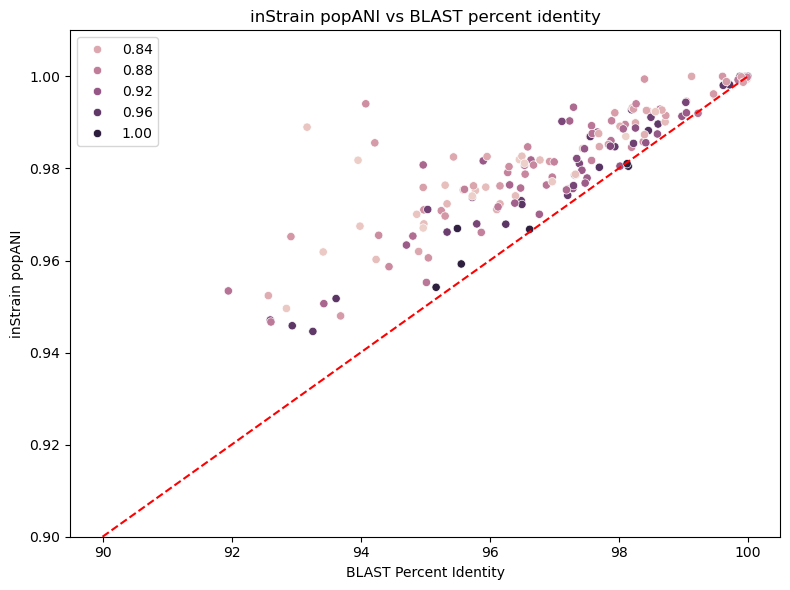

In [6]:
# compare instrain popANI to blast ANI
import polars as pl

instrain_df_lst = []

for i in range(1, 6):
    # read coverage file
    cov = pl.read_csv(f'readsim/split_{i}_reads_cov.txt', separator='\t').rename({'tname':'qname'})

    # load instrain data
    instrain = (
        pl.read_csv(f'uhvdb_sylph_profile/split_{i}/instrain_profile/output/instrain_profile_scaffold_info.tsv', separator='\t', ignore_errors=True)
    )

    instrain_top_hit = (
        pl.read_csv('uhvdb.anicalc.tsv', separator='\t')
            .filter(pl.col('qname').is_in(set(cov['qname'])))
            .join(instrain, left_on='tname', right_on='scaffold', how='right') # keep only blast results with instrain genome
            .with_columns([
                ((pl.col('pid') * (pl.col('qcov')))/10000).alias('qani'),
                ((pl.col('pid') * (pl.col('tcov')))/10000).alias('tani')
            ])
            .sort('tani', descending=True)
            .group_by('scaffold', maintain_order=True)
            .first() # identify most similar assembled input genome for each instrain genome
            .filter(pl.col('breadth') >= 0.8)
            [['scaffold', 'qname', 'qani', 'tani', 'tcov', 'pid', 'coverage', 'breadth', 'coverage_median', 'conANI_reference', 'popANI_reference']]
    )

    instrain_df_lst.append(instrain_top_hit)

# plot scatterplot of pid vs popANI_reference
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pl.concat(instrain_df_lst),
    x='pid',
    y='popANI_reference',
    hue='breadth'
)
plt.ylim(0.9, 1.01)
plt.title('inStrain popANI vs BLAST percent identity')
plt.xlabel('BLAST Percent Identity')
plt.ylabel('inStrain popANI')
plt.legend()
plt.tight_layout()  # adjust layout to make room
# add line across diagonal
plt.plot([90, 100], [0.9, 1.0], color='r', linestyle='--')
plt.show()

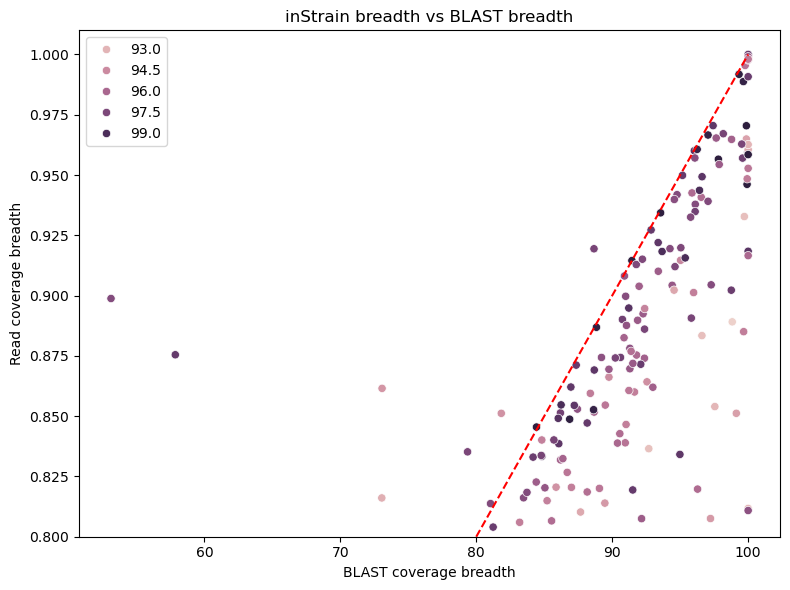

In [9]:
# plot scatterplot of pid vs popANI_reference
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pl.concat(instrain_df_lst).filter(pl.col('coverage_median') >= 3),
    x='tcov',
    y='breadth',
    hue='pid'
)
plt.ylim(0.8, 1.01)
plt.title('inStrain breadth vs BLAST breadth')
plt.xlabel('BLAST coverage breadth')
plt.ylabel('Read coverage breadth')
plt.legend()
plt.tight_layout()  # adjust layout to make room
# add line across diagonal
plt.plot([80, 100], [0.8, 1.0], color='r', linestyle='--')
plt.show()